# 18 · Centering Benchmark  (`18_nonvlm_centering_benchmark`)

Makes inner-boundary accuracy **measurable**, so any new rule can be scored
objectively before touching production. Three complementary references:

| Reference | Truth source | Cost | What it measures |
|---|---|---|---|
| **Synthetic** | exact (we draw the border) | free, ∞ samples | absolute per-side error in % |
| **PSA-grade consistency** | actual PSA grades (679 cards) | free | does deviation track grade? outliers? |
| **Hand-labeled** | human clicks (scaffold provided) | manual | real-card per-side error |
| **Invariance** | self-consistency | free | flip-symmetry, scale stability (bug catcher) |

A centering method is any `fn(warped_bgr, cb) -> {x1,y1,x2,y2}` (normalized).
`benchmark(name, fn)` scores it on all of the above.

> Motivation: on the 679 real cards, current centering deviation has **~0
> correlation with PSA grade** and PSA-10s measure ~12% off (should be ≤5%) —
> a systematic inner-boundary problem. This harness is how we fix it rigorously.

In [1]:
import os, sys, glob, warnings, importlib
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["CARD_DETECTOR"] = "seg"
sys.path.insert(0, "."); sys.path.insert(0, "../backend")
from dotenv import load_dotenv
load_dotenv("../.env.local", override=True); load_dotenv("../backend/.env", override=False)
import grader; importlib.reload(grader)
import nonvlm_cv as N; importlib.reload(N)
from scipy.stats import spearmanr

BASE = Path("feature_extraction_dataset"); OUT = Path("diag"); OUT.mkdir(exist_ok=True)
RNG = np.random.default_rng(7)

# A centering METHOD is fn(warped_bgr, cb_list) -> content_region dict {x1,y1,x2,y2} (normalized).
def method_current(warped, cb):
    return N.compute_centering_hybrid(warped, cb)["content_region"]

def insets_of(cb, cr):
    x1,y1,x2,y2 = cb; iw,ih = x2-x1, y2-y1
    return {"L": max(0.,(cr["x1"]-x1))/iw, "R": max(0.,(x2-cr["x2"]))/iw,
            "T": max(0.,(cr["y1"]-y1))/ih, "B": max(0.,(y2-cr["y2"]))/ih}
print("ready")

ready


## 1 · Synthetic ground truth  *(exact, free)*

Draw cards with a **known** colored border at a known centering ratio, fill the
interior with random artwork, and optionally inject the two real failure modes:
a **gradual** border ramp (Snorlax) and a **low-chroma/metal** border. Because we
drew the border, the true inner boundary is known exactly.

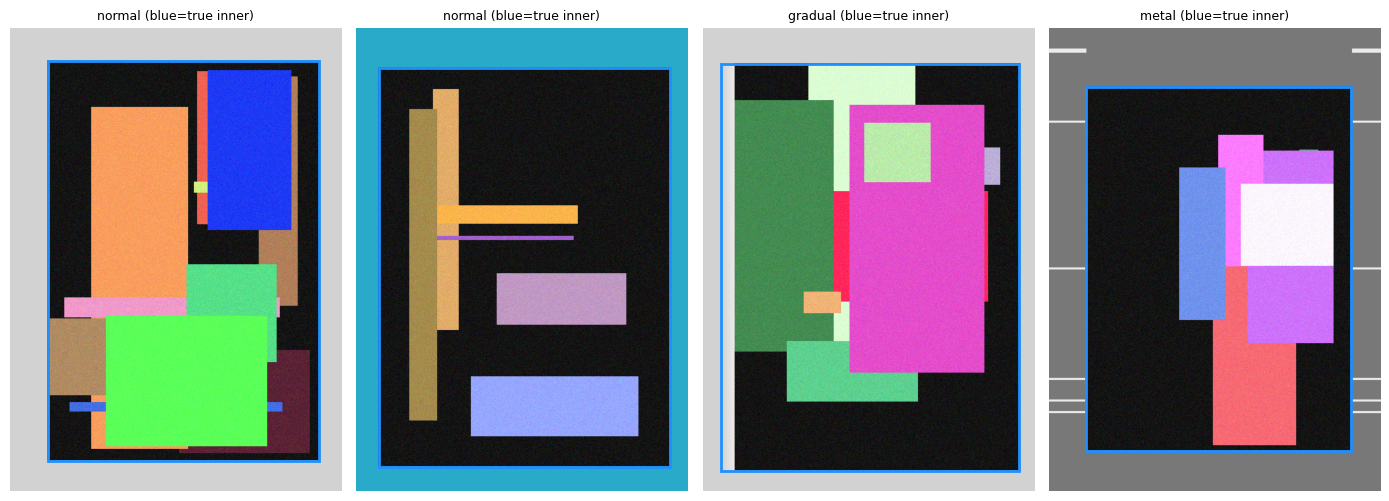

In [2]:
PALETTE = [(40,90,210),(40,170,230),(60,160,70),(200,170,40),(180,60,60),
           (150,90,200),(210,210,210),(120,120,120)]  # BGR border colors incl. silver/grey

def make_synthetic(W=630, H=880, insets=None, border_bgr=None, mode="normal", seed=0):
    """Return (warped_bgr, cb, true_cr). insets = dict L/R/T/B fractions."""
    rng = np.random.default_rng(seed)
    if insets is None:
        # random centering: mostly mild, sometimes off-center
        base = rng.uniform(0.04, 0.09)
        skew = rng.uniform(0, 0.05)
        insets = {"L":base+skew, "R":base, "T":base+rng.uniform(0,0.04), "B":base}
    border_bgr = border_bgr or PALETTE[rng.integers(len(PALETTE))]
    img = np.zeros((H,W,3), np.uint8)
    # border fills the whole card; interior = content
    img[:] = border_bgr
    x1,x2 = int(insets["L"]*W), int(W-insets["R"]*W)
    y1,y2 = int(insets["T"]*H), int(H-insets["B"]*H)
    # interior artwork: random colored blocks + noise
    inner = np.zeros((y2-y1, x2-x1, 3), np.uint8)
    for _ in range(rng.integers(6,14)):
        c = tuple(int(v) for v in rng.integers(0,255,3))
        a = (int(rng.uniform(0,inner.shape[1])), int(rng.uniform(0,inner.shape[0])))
        b = (int(rng.uniform(0,inner.shape[1])), int(rng.uniform(0,inner.shape[0])))
        cv2.rectangle(inner, a, b, c, -1)
    inner = cv2.add(inner, rng.integers(0,40,inner.shape,dtype=np.int16).astype(np.uint8))
    img[y1:y2, x1:x2] = inner

    if mode == "gradual":
        # cream ramp between border and content on the LEFT (the Snorlax case)
        ramp_w = int(0.04*W)
        for i in range(ramp_w):
            a = i/ramp_w
            img[y1:y2, x1+i] = (np.array(border_bgr)*(1-a) + np.array([235,235,240])*a).astype(np.uint8)
    if mode == "metal":
        # low-chroma reflective border: add bright streaks
        for _ in range(8):
            yy = rng.integers(0,H)
            img[max(0,yy-2):yy+2, :x1] = (235,235,235)
            img[max(0,yy-2):yy+2, x2:] = (235,235,235)
    cb = [0.0,0.0,1.0,1.0]
    true_cr = {"x1":x1/W, "y1":y1/H, "x2":x2/W, "y2":y2/H}
    return img, cb, true_cr

# show a few examples
fig, axes = plt.subplots(1,4,figsize=(14,5))
for ax,(mode,sd) in zip(axes,[("normal",1),("normal",2),("gradual",3),("metal",4)]):
    im,cb,tcr = make_synthetic(mode=mode,seed=sd)
    ax.imshow(cv2.cvtColor(im,cv2.COLOR_BGR2RGB))
    h,w=im.shape[:2]
    from matplotlib.patches import Rectangle
    ax.add_patch(Rectangle((tcr["x1"]*w,tcr["y1"]*h),(tcr["x2"]-tcr["x1"])*w,(tcr["y2"]-tcr["y1"])*h,
                 fill=False,edgecolor="#1e90ff",lw=2))
    ax.set_title(f"{mode} (blue=true inner)",fontsize=9); ax.axis("off")
plt.tight_layout(); plt.savefig(OUT/"synthetic_examples.png",dpi=90); plt.show()

In [3]:
def score_synthetic(fn, n=60, modes=("normal","normal","gradual","metal")):
    """Per-side absolute error (% of card dim) of fn vs known truth."""
    rows = []
    for i in range(n):
        mode = modes[i % len(modes)]
        im, cb, tcr = make_synthetic(mode=mode, seed=1000+i)
        try:
            cr = fn(im, cb)
        except Exception:
            continue
        ti, pi = insets_of(cb, tcr), insets_of(cb, cr)
        for s in "LRTB":
            rows.append({"mode": mode, "side": s, "err_pct": abs(pi[s]-ti[s])*100,
                         "true_pct": ti[s]*100, "pred_pct": pi[s]*100})
    d = pd.DataFrame(rows)
    summary = d.groupby("mode")["err_pct"].agg(["mean","median","max"]).round(2)
    overall = d["err_pct"].agg(["mean","median","max"]).round(2)
    return d, summary, overall

dsyn, syn_by_mode, syn_overall = score_synthetic(method_current, n=80)
print("Synthetic per-side error (% of card dimension) — CURRENT method:")
print(syn_by_mode.to_string())
print(f"\nOVERALL  mean={syn_overall['mean']}%  median={syn_overall['median']}%  max={syn_overall['max']}%")
print("(lower = tighter to the true inner boundary; <2% is good)")

Synthetic per-side error (% of card dimension) — CURRENT method:
         mean  median   max
mode                       
gradual  0.64    0.16  3.65
metal    0.16    0.16  0.48
normal   0.18    0.16  3.75

OVERALL  mean=0.29%  median=0.16%  max=3.75%
(lower = tighter to the true inner boundary; <2% is good)


## 2 · PSA-grade consistency  *(free, all real graded cards)*

In [ ]:
def psa_consistency(csv=None):
    """VALID centering check. NOTE: grade-correlation is EXPECTED ~0 because PSA
    grade = min(centering,corners,edges,surface) — low grades are usually driven
    by NON-centering defects. The valid necessary test is: PSA-10s MUST be
    well-centered (<=60/40 = <=10% deviation). So we score the PSA-10 tail."""
    if (BASE/"cv_features.csv").exists():
        df=pd.read_csv(BASE/"cv_features.csv"); lr,tb="cen.lr_deviation","cen.tb_deviation"
    else:
        df=pd.read_csv(BASE/"feature_dataset.csv")
        df[lr:="cen.lr_deviation"]=(df["det.lr_pct_left"]-50).abs()
        df[tb:="cen.tb_deviation"]=(df["det.tb_pct_top"]-50).abs()
    df=df[df.get("error",pd.Series("",index=df.index)).isna() |
          (df.get("error",pd.Series("",index=df.index)).astype(str).str.strip()=="")].copy()
    if "is_sir" not in df.columns:
        m=pd.read_csv(BASE/"metadata.csv")[["filename","actual_psa","is_sir"]].rename(columns={"filename":"file"})
        m["is_sir"]=(m["is_sir"].astype(str).str.strip().str.lower()=="yes")
        df=df.merge(m.drop_duplicates(["file","actual_psa"]),on=["file","actual_psa"],how="left")
    df["is_sir"]=df["is_sir"].fillna(False).astype(bool)
    df["worst_dev"]=df[[lr,tb]].max(axis=1)
    b=df[~df.is_sir]; p10=b[b.actual_psa==10]
    # PRIMARY metric: bordered PSA-10 within tolerance + gross-error rate
    pct_ok   = float((p10.worst_dev<=10).mean()*100)        # within ~60/40
    pct_gross= float((p10.worst_dev>25).mean()*100)         # impossible for a 10 -> error
    med      = float(p10.worst_dev.median())
    # secondary (informational only): gross outliers across all high grades
    sus=((df.actual_psa>=9)&(df.worst_dev>25)).sum(); nhi=(df.actual_psa>=9).sum()
    return {"bordered_PSA10_within60/40_%":round(pct_ok,1),
            "bordered_PSA10_gross_err_%":round(pct_gross,1),
            "bordered_PSA10_median_dev_%":round(med,1),
            "all_PSA9-10_gross_outliers":f"{sus}/{nhi}"}, df

m,_=psa_consistency()
print("PSA-10 centering check (bordered cards; PSA-10 MUST be well-centered):")
for k,v in m.items(): print(f"  {k:32} {v}")
print("\n(Higher within-60/40 % and lower gross-err % = better. Grade-correlation")
print(" intentionally dropped: it is ~0 by construction, not a quality signal.)")

## 3 · Invariance tests  *(no ground truth — pure bug-catchers)*

In [5]:
def invariance_tests(fn, n=12):
    """Flip-symmetry: horizontal flip must swap L/R, keep T/B.
       Scale-stability: rescaling the warp must not change the ratio."""
    paths=[]
    for gr in (5,7,9,10):
        paths += sorted(glob.glob(str(BASE/f"{gr}/*_front.jpeg")))[:n//4]
    flip_err=[]; scale_err=[]
    for p in paths:
        img=cv2.imread(p); det=N.detect_and_warp(img,detector="seg",out_size=N.CV_WARP_SIZE)
        wp,cb=det["warped"],det["cb"]
        cr=fn(wp,cb); ins=insets_of(cb,cr)
        # flip horizontally
        crf=fn(wp[:,::-1].copy(),cb); insf=insets_of(cb,crf)
        flip_err.append(abs(insf["L"]-ins["R"])*100); flip_err.append(abs(insf["R"]-ins["L"])*100)
        flip_err.append(abs(insf["T"]-ins["T"])*100)  # top unchanged
        # scale the warp 0.8x
        wp2=cv2.resize(wp,(int(wp.shape[1]*0.8),int(wp.shape[0]*0.8)))
        cr2=fn(wp2,cb); ins2=insets_of(cb,cr2)
        for s in "LRTB": scale_err.append(abs(ins2[s]-ins[s])*100)
    return np.mean(flip_err), np.mean(scale_err)

flip_e, scale_e = invariance_tests(method_current)
print(f"Flip-symmetry error : {flip_e:.2f}%  (L/R should swap exactly; <1% = good)")
print(f"Scale-stability err : {scale_e:.2f}%  (ratio should be scale-invariant; <1% = good)")

Flip-symmetry error : 0.03%  (L/R should swap exactly; <1% = good)
Scale-stability err : 0.06%  (ratio should be scale-invariant; <1% = good)


## 4 · Hand-labeled ground truth  *(scaffold)*

Run `label_card(path)` and click **4 points** on the inner boundary in this order:
**left edge, right edge, top edge, bottom edge** (click anywhere along each edge).
Labels append to `diag/centering_labels.csv`. Then `score_against_labels(fn)` reports
real-card per-side error. Label ~80 cards stratified by `border_type` × grade.

In [6]:
LABELS = OUT/"centering_labels.csv"

def label_card(path, detector="seg"):
    """Interactive: click left, right, top, bottom inner-boundary points."""
    img=cv2.imread(path); det=N.detect_and_warp(img,detector=detector,out_size=N.CV_WARP_SIZE)
    wp=det["warped"]; h,w=wp.shape[:2]
    fig,ax=plt.subplots(figsize=(7,9)); ax.imshow(cv2.cvtColor(wp,cv2.COLOR_BGR2RGB))
    ax.set_title("click: LEFT, RIGHT, TOP, BOTTOM inner-edge points")
    pts=plt.ginput(4,timeout=0); plt.close(fig)
    if len(pts)<4: print("need 4 clicks"); return
    (lx,_),(rx,_),(_,ty),(_,by)=pts
    row={"file":os.path.basename(path),"path":os.path.abspath(path),
         "x1":lx/w,"x2":rx/w,"y1":ty/h,"y2":by/h}
    df=pd.read_csv(LABELS) if LABELS.exists() else pd.DataFrame()
    df=pd.concat([df,pd.DataFrame([row])],ignore_index=True).drop_duplicates("path",keep="last")
    df.to_csv(LABELS,index=False); print(f"labeled {row['file']} ({len(df)} total)")

def score_against_labels(fn):
    if not LABELS.exists(): print("No labels yet — run label_card() first."); return None
    lab=pd.read_csv(LABELS); rows=[]
    for _,r in lab.iterrows():
        if not os.path.exists(r["path"]): continue
        det=N.detect_and_warp(cv2.imread(r["path"]),detector="seg",out_size=N.CV_WARP_SIZE)
        cr=fn(det["warped"],det["cb"])
        ti=insets_of(det["cb"],{k:r[k] for k in ("x1","y1","x2","y2")}); pi=insets_of(det["cb"],cr)
        for s in "LRTB": rows.append({"side":s,"err_pct":abs(pi[s]-ti[s])*100})
    if not rows: return None
    d=pd.DataFrame(rows); print(f"Hand-label per-side error: mean={d.err_pct.mean():.2f}%  median={d.err_pct.median():.2f}%  (n={len(lab)} cards)")
    return d

print(f"Hand-label scaffold ready. Labels file: {LABELS}")
print("In a LIVE notebook: label_card('feature_extraction_dataset/9/scraped_001_front.jpeg')")

Hand-label scaffold ready. Labels file: diag/centering_labels.csv
In a LIVE notebook: label_card('feature_extraction_dataset/9/scraped_001_front.jpeg')


## 5 · Unified scorecard — run on any method

In [7]:
def benchmark(name, fn, n_syn=80, n_inv=12):
    print("="*60); print(f"BENCHMARK: {name}"); print("="*60)
    _,_,so = score_synthetic(fn, n=n_syn)
    print(f"  Synthetic  : mean {so['mean']}%  median {so['median']}%  max {so['max']}%")
    pm,_ = psa_consistency()
    print(f"  PSA-10 within 60/40: {pm['bordered_PSA10_within60/40_%']}%  |  gross-err: {pm['bordered_PSA10_gross_err_%']}%  |  median dev: {pm['bordered_PSA10_median_dev_%']}%")
    fe,se = invariance_tests(fn, n=n_inv)
    print(f"  Invariance : flip {fe:.2f}%  scale {se:.2f}%")
    return {"name":name,"syn_mean":so["mean"],"syn_median":so["median"],
            "psa10_within_6040":pm["bordered_PSA10_within60/40_%"],"psa10_gross_err":pm["bordered_PSA10_gross_err_%"],
            "flip":round(fe,2),"scale":round(se,2)}

baseline = benchmark("current (compute_centering_hybrid)", method_current)
pd.DataFrame([baseline])

### How to test a new rule
```python
def method_new(warped, cb):
    ...  # your candidate inner-boundary logic
    return {"x1":..., "y1":..., "x2":..., "y2":...}

benchmark("new rule", method_new)   # compare every number to the baseline above
```
Adopt the rule only if synthetic error ↓, PSA Spearman becomes more negative, and
invariance stays clean — with no regression on `18_nonvlm_boundaries`.

## Notes & roadmap
- **Synthetic** gives exact accuracy; the current method's synthetic error on `gradual`/`metal` modes quantifies the two real failure modes.
- **PSA-consistency** is the dataset-wide reality check (Spearman should move toward −1 as we improve).
- Candidate rules to benchmark next: 4-line rectangle RANSAC fit, hysteresis colour-model thresholding, per-row median voting, edge-confirmation, border-type routing, sub-pixel refinement.
- Each must beat the baseline scorecard before going near production centering.